In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv('trading_data.csv')
df.head()

,Day,Strategy,Daily_Return
0,1,Algo Alpha,0.004484
1,2,Algo Alpha,0.001309
2,3,Algo Alpha,0.005238
3,4,Algo Alpha,0.009615
4,5,Algo Alpha,0.000829


In [67]:
df["Strategy"].unique()

array(['Algo Alpha', 'Yolo Beta', 'Gamma Hedge'], dtype=object)

<Axes: xlabel='Strategy', ylabel='Daily_Return'>

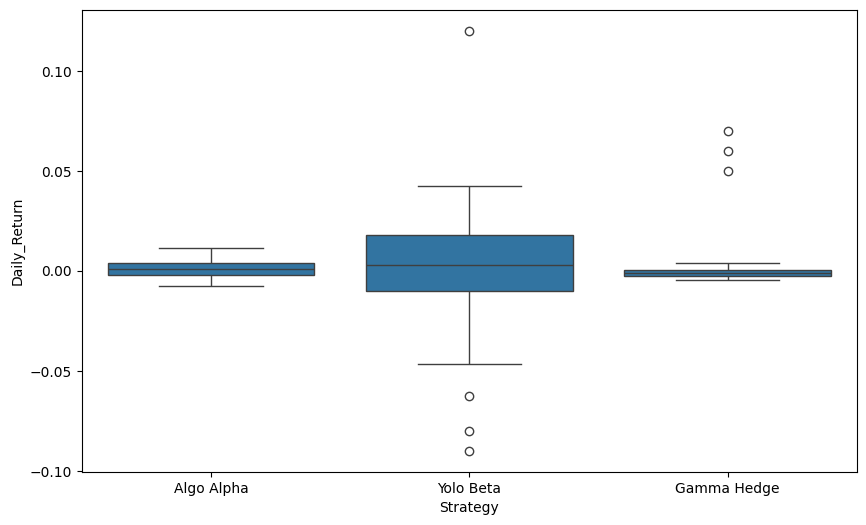

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Strategy', y='Daily_Return', data=df)

In [69]:
df_pivot = df.pivot_table(values='Daily_Return', index='Day', columns='Strategy')
df_pivot

Strategy,Algo Alpha,Gamma Hedge,Yolo Beta
Day,,,
1,0.004484,-0.003831,0.011102
2,0.001309,-0.001841,-0.006627
3,0.005238,-0.001685,-0.013923
4,0.009615,-0.002605,0.018292
5,0.000829,-0.001323,0.028775
6,0.000829,0.050000,0.026282
7,0.009896,0.002772,-0.017980
8,0.005837,-0.000651,-0.004730
9,-0.000347,-0.000485,0.011282


Algo Alpha
Gamma Hedge
Yolo Beta


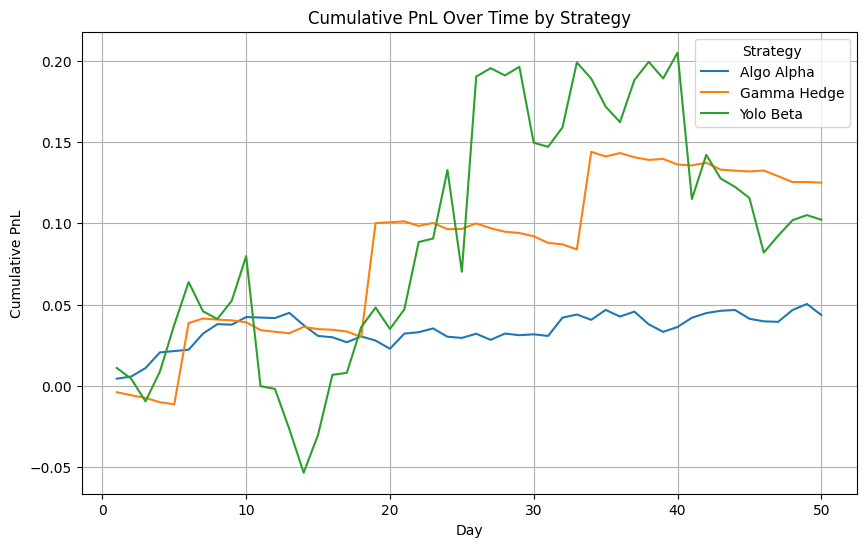

In [72]:
plt.figure(figsize=(10, 6))
for strategy in df_pivot.columns:
    print(strategy)
    plt.plot(df_pivot.index, df_pivot[strategy].cumsum(), label=strategy)

plt.title('Cumulative PnL Over Time by Strategy')
plt.xlabel('Day')
plt.ylabel('Cumulative PnL')
plt.legend(title='Strategy')
plt.grid(True)
plt.show()

In [ ]:
df[df["Strategy"] == "Gamma Hedge"]

,Day,Strategy,Daily_Return,Pnl
100,1,Gamma Hedge,-0.003831,-0.003831
101,2,Gamma Hedge,-0.001841,-0.005672
102,3,Gamma Hedge,-0.001685,-0.007357
103,4,Gamma Hedge,-0.002605,-0.009962
104,5,Gamma Hedge,-0.001323,-0.011285
105,6,Gamma Hedge,0.050000,0.038715
106,7,Gamma Hedge,0.002772,0.041488
107,8,Gamma Hedge,-0.000651,0.040837
108,9,Gamma Hedge,-0.000485,0.040352
109,10,Gamma Hedge,-0.001149,0.039203


Algo Alpha PnL: 0.04363152368596458


C:\Users\Lloyd2103\AppData\Local\Temp\ipykernel_9040\1493449949.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


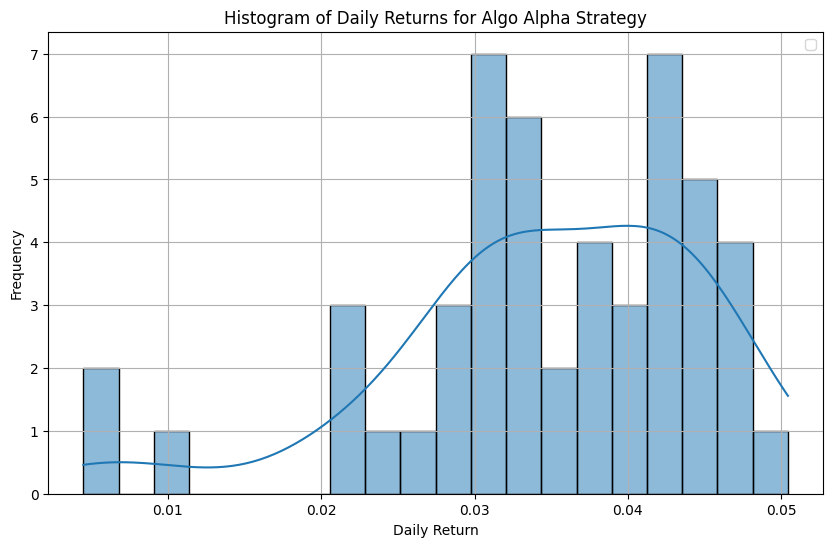

Yolo Beta PnL: 0.1022309426879909


C:\Users\Lloyd2103\AppData\Local\Temp\ipykernel_9040\1493449949.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


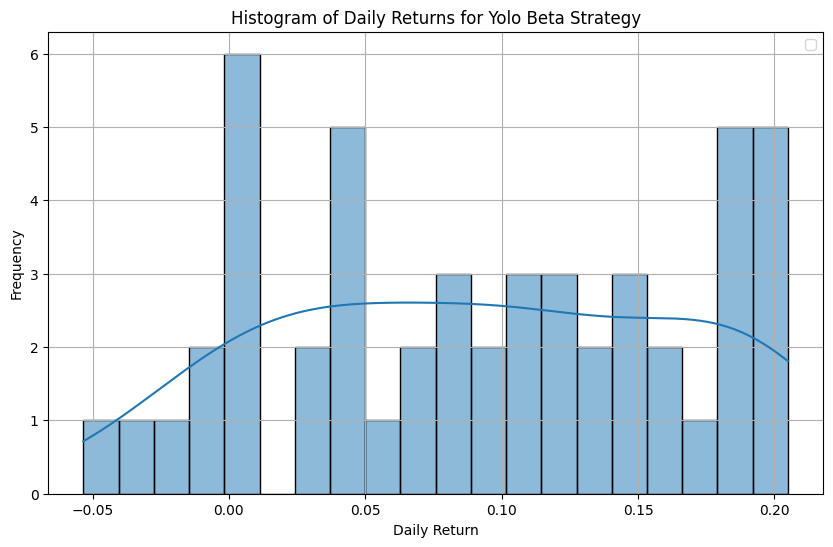

Gamma Hedge PnL: 0.12503031112912935


C:\Users\Lloyd2103\AppData\Local\Temp\ipykernel_9040\1493449949.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


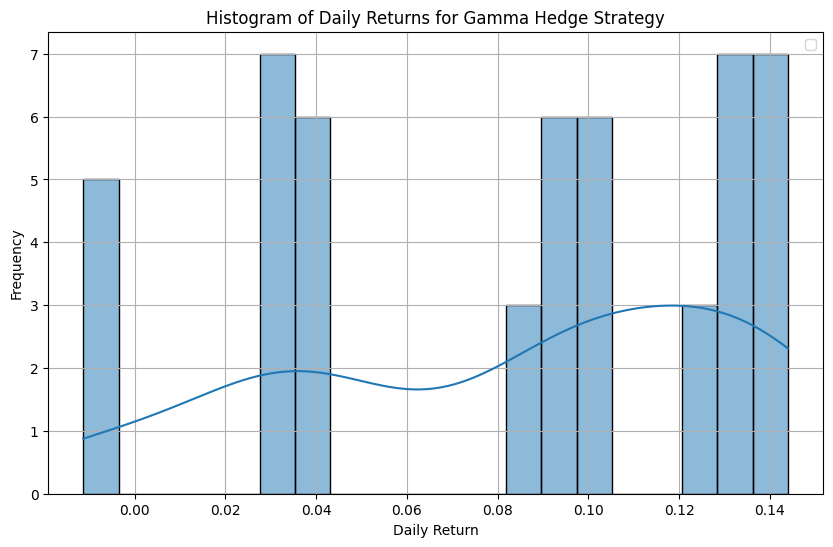

In [79]:
for strategy in df["Strategy"].unique():
    Pnl = df_pivot[strategy].cumsum()
    print(f"{strategy} PnL: {Pnl.iloc[-1]}")
    plt.figure(figsize=(10, 6))
    sns.histplot(Pnl, bins=20, alpha=0.5, kde=True)
    plt.title(f'Histogram of Daily Returns for {strategy} Strategy')
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.legend()
    plt.show()